# COMP 5630/6630 — Assignment 2 (Fall 2025)
**Author:** Carter Hand  
**Environment:** Google Colab (Python 3)

## README — How to run
1. Run cells from top to bottom.  
2. Dependencies: numpy, pandas, matplotlib, scikit-learn  
3. Parts:
   - Part 1: Data loading, split, standardization (sklearn)
   - Part 2: Logistic regression from scratch (NO sklearn)
   - Part 3: LogisticRegression (no regularization)
   - Part 4: L1-regularized LogisticRegression (liblinear)
   - Part 5/6: Evaluation & reflection

## GenAI Declaration
I used ChatGPT (GPT-5) to help write some boilerplate code, and create result tables/plots. All code generated was reviewed and executed by me, and all interpretations and conclusions are my own.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix

# 1) Load data
wine = load_wine()
X_raw = wine.data
y = wine.target
feature_names = wine.feature_names
classes = wine.target_names

print("X shape:", X_raw.shape)   # (n_samples, n_features)
print("y distribution:", {k:int(v) for k,v in zip(*np.unique(y, return_counts=True))})
print("Features:", feature_names)
print("Classes:", classes)

# 2) Train/test split (80/20), stratified, random_state=15
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.2, stratify=y, random_state=15
)

# 3) Standardize features (fit on train, transform both)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test  = scaler.transform(X_test_raw)

print("Train/Test shapes:", X_train.shape, X_test.shape)


X shape: (178, 13)
y distribution: {np.int64(0): 59, np.int64(1): 71, np.int64(2): 48}
Features: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']
Classes: ['class_0' 'class_1' 'class_2']
Train/Test shapes: (142, 13) (36, 13)


In [ ]:
# Sigmoid and OvR helpers
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

def make_ovr_labels(y, c):
    """Binary labels for class-vs-rest."""
    return (y == c).astype(np.float64)

def loglik_and_grad(w, X, y_bin):
    """
    Log-likelihood (sum over samples) and gradient for logistic regression.
    y_bin in {0,1}, X shape (n,d), w shape (d,)
    """
    z = X @ w
    p = sigmoid(z)  # predicted prob of y=1
    # Log-likelihood: sum[y*log(p) + (1-y)*log(1-p)]
    eps = 1e-12
    ll = np.sum(y_bin * np.log(p + eps) + (1 - y_bin) * np.log(1 - p + eps))
    # Gradient: X^T (y - p)
    grad = X.T @ (y_bin - p)
    return ll, grad

def fit_logreg_gd(X, y_bin, lr=1e-4, iters=7000):
    """
    Gradient ascent on log-likelihood for logistic regression (bias included by augmenting X).
    """
    # Add bias column
    Xb = np.hstack([np.ones((X.shape[0], 1)), X])
    w = np.zeros(Xb.shape[1])
    history = []

    for t in range(iters):
        ll, grad = loglik_and_grad(w, Xb, y_bin)
        w = w + lr * grad                # ascent
        if (t+1) % 100 == 0 or t == 0:
            history.append(ll)
    return w, history

def predict_proba_from_scratch(X, w):
    Xb = np.hstack([np.ones((X.shape[0], 1)), X])
    return sigmoid(Xb @ w)

def predict_class_from_scratch(X, w):
    return (predict_proba_from_scratch(X, w) >= 0.5).astype(int)


In [ ]:
LR = 1e-4
ITERS = 7000

w_ovr = {}
hist_ovr = {}
train_acc_ovr = {}

for c in [0, 1, 2]:
    y_train_bin = make_ovr_labels(y_train, c)
    w_c, hist_c = fit_logreg_gd(X_train, y_train_bin, lr=LR, iters=ITERS)
    w_ovr[c] = w_c
    hist_ovr[c] = hist_c

    # Training accuracy for this binary task
    yhat_bin = predict_class_from_scratch(X_train, w_c)
    acc = accuracy_score(y_train_bin, yhat_bin)
    train_acc_ovr[c] = acc

print("Training accuracy (from-scratch OvR):", train_acc_ovr)


Training accuracy (from-scratch OvR): {0: 1.0, 1: 0.9929577464788732, 2: 1.0}


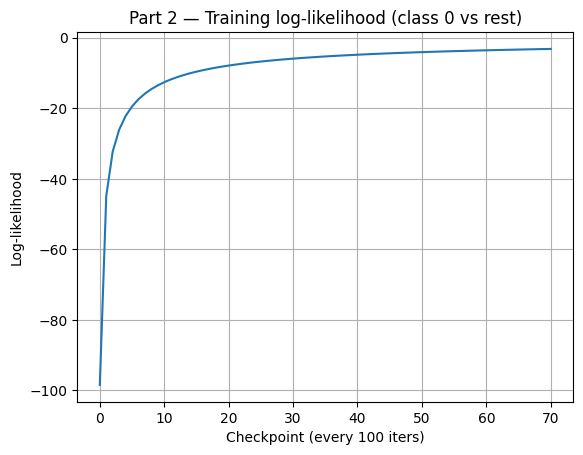

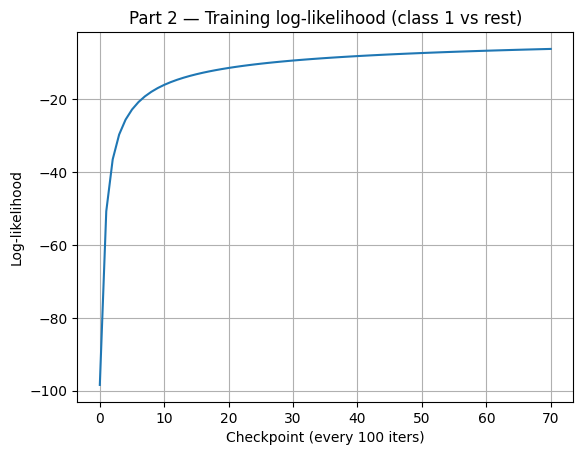

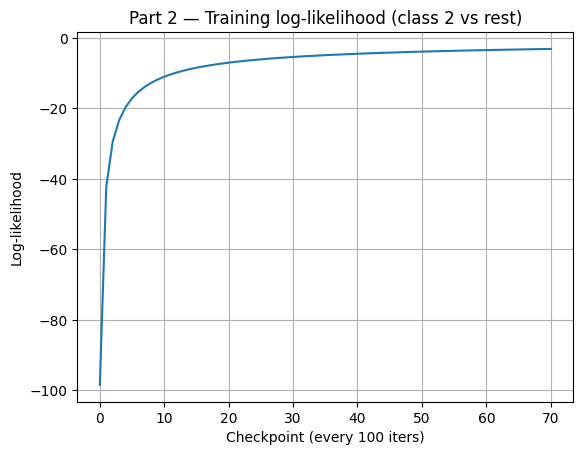

In [ ]:
for c in [0,1,2]:
    plt.figure()
    plt.plot(hist_ovr[c])
    plt.title(f"Part 2 — Training log-likelihood (class {c} vs rest)")
    plt.xlabel("Checkpoint (every 100 iters)")
    plt.ylabel("Log-likelihood")
    plt.grid(True)
    plt.show()

In [ ]:
from sklearn.linear_model import LogisticRegression

# Fit one multinomial-ish OvR set by training separate binary models
models_none = {}
weights_none = {}
train_acc_none = {}

for c in [0,1,2]:
    y_train_bin = make_ovr_labels(y_train, c)
    clf = LogisticRegression(penalty=None, solver='lbfgs', max_iter=1000)
    clf.fit(X_train, y_train_bin)
    models_none[c] = clf
    weights_none[c] = np.hstack([clf.intercept_, clf.coef_.ravel()])  # [bias, w...]

    # Training accuracy for the binary task
    yhat_bin = (clf.predict_proba(X_train)[:,1] >= 0.5).astype(int)
    train_acc_none[c] = accuracy_score(y_train_bin, yhat_bin)

print("Training accuracy (sklearn, no reg, OvR):", train_acc_none)

# Feature ranking: absolute weight
for c in [0,1,2]:
    w = weights_none[c][1:]
    order = np.argsort(-np.abs(w))
    top3 = [(feature_names[i], w[i], abs(w[i])) for i in order[:3]]
    df = pd.DataFrame(top3, columns=["Feature", "Weight", "|Weight|"])
    print(f"\nClass {c} vs Rest — top 3 features (no reg):")
    print(df)

# Build a multi-class predictor from the three OvR models for test confusion matrix
def ovr_predict(models, X):
    # pick class with highest P(y=1|class c)
    scores = np.vstack([m.predict_proba(X)[:,1] for m in [models[0], models[1], models[2]]]).T
    return np.argmax(scores, axis=1)

y_pred_test_none = ovr_predict(models_none, X_test)
cm_none = confusion_matrix(y_test, y_pred_test_none)
acc_test_none = accuracy_score(y_test, y_pred_test_none)
print("\nTest accuracy (OvR, no reg):", acc_test_none)
print("Confusion matrix (test, no reg):\n", cm_none)


Training accuracy (sklearn, no reg, OvR): {0: 1.0, 1: 1.0, 2: 1.0}

Class 0 vs Rest — top 3 features (no reg):
             Feature    Weight  |Weight|
0  alcalinity_of_ash -6.712904  6.712904
1            proline  6.554616  6.554616
2         flavanoids  5.656964  5.656964

Class 1 vs Rest — top 3 features (no reg):
           Feature     Weight   |Weight|
0  color_intensity -16.497793  16.497793
1          proline -15.489845  15.489845
2              ash  -8.200369   8.200369

Class 2 vs Rest — top 3 features (no reg):
                        Feature    Weight  |Weight|
0               color_intensity  7.019608  7.019608
1                    flavanoids -5.221182  5.221182
2  od280/od315_of_diluted_wines -3.503859  3.503859

Test accuracy (OvR, no reg): 0.9722222222222222
Confusion matrix (test, no reg):
 [[12  0  0]
 [ 0 14  0]
 [ 0  1  9]]


In [ ]:
models_l1 = {}
weights_l1 = {}
train_acc_l1 = {}

for c in [0,1,2]:
    y_train_bin = make_ovr_labels(y_train, c)
    clf = LogisticRegression(penalty='l1', solver='liblinear', C=0.1, max_iter=2000)
    clf.fit(X_train, y_train_bin)
    models_l1[c] = clf
    weights_l1[c] = np.hstack([clf.intercept_, clf.coef_.ravel()])

    yhat_bin = (clf.predict_proba(X_train)[:,1] >= 0.5).astype(int)
    train_acc_l1[c] = accuracy_score(y_train_bin, yhat_bin)

print("Training accuracy (sklearn, L1, OvR):", train_acc_l1)

# Comparison table per class
for c in [0,1,2]:
    w_none = weights_none[c][1:]  # exclude bias
    w_l1   = weights_l1[c][1:]
    df = pd.DataFrame({
        "Feature": feature_names,
        "Weight (No Reg)": w_none,
        "|Weight|": np.abs(w_none),
        "Weight (L1)": w_l1,
        "Zeroed?": np.isclose(w_l1, 0.0)
    }).sort_values("|Weight|", ascending=False)
    print(f"\nClass {c} vs Rest — Feature weights (No Reg vs L1):")
    print(df.head(10))

y_pred_test_l1 = ovr_predict(models_l1, X_test)
cm_l1 = confusion_matrix(y_test, y_pred_test_l1)
acc_test_l1 = accuracy_score(y_test, y_pred_test_l1)
print("\nTest accuracy (OvR, L1):", acc_test_l1)
print("Confusion matrix (test, L1):\n", cm_l1)



Training accuracy (sklearn, L1, OvR): {0: 0.971830985915493, 1: 0.9577464788732394, 2: 0.9859154929577465}

Class 0 vs Rest — Feature weights (No Reg vs L1):
                         Feature  Weight (No Reg)  |Weight|  Weight (L1)  \
3              alcalinity_of_ash        -6.712904  6.712904    -0.019771   
12                       proline         6.554616  6.554616     1.351681   
6                     flavanoids         5.656964  5.656964     0.776836   
11  od280/od315_of_diluted_wines         5.322143  5.322143     0.000000   
0                        alcohol         4.751379  4.751379     0.314232   
2                            ash         4.448355  4.448355     0.000000   
1                     malic_acid         1.943117  1.943117     0.000000   
8                proanthocyanins        -1.605016  1.605016     0.000000   
4                      magnesium         1.220877  1.220877     0.000000   
10                           hue        -1.109334  1.109334     0.000000   

    Z

In [ ]:
# Count how many features zeroed by L1 (exclude bias)
zero_counts = {}
for c in [0,1,2]:
    zero_counts[c] = int(np.isclose(weights_l1[c][1:], 0.0).sum())

summary = pd.DataFrame({
    "Model": ["No Reg", "L1"],
    "Train Acc (c=0)": [train_acc_none[0], train_acc_l1[0]],
    "Train Acc (c=1)": [train_acc_none[1], train_acc_l1[1]],
    "Train Acc (c=2)": [train_acc_none[2], train_acc_l1[2]],
    "Test Acc (multi-class)": [accuracy_score(y_test, ovr_predict(models_none, X_test)),
                               accuracy_score(y_test, ovr_predict(models_l1, X_test))]
})

print("Performance summary:\n", summary)
print("\nZeroed features by L1:", zero_counts)


Performance summary:
     Model  Train Acc (c=0)  Train Acc (c=1)  Train Acc (c=2)  \
0  No Reg         1.000000         1.000000         1.000000   
1      L1         0.971831         0.957746         0.985915   

   Test Acc (multi-class)  
0                0.972222  
1                1.000000  

Zeroed features by L1: {0: 9, 1: 7, 2: 8}


## Part 6 — Analysis & Reflection

**1. Were the most important features consistent across all three class-vs-rest classifiers?**

The most influential features showed partial consistency.

  - Proline and color_intensity appeared as top predictors for multiple classes, indicating they are strong global discriminators.

  - However, other features (such as alcalinity_of_ash or flavanoids) varied by class, showing class-specific relationships within the wine data.

**2.Did any features appear important for one class but not others?**

Yes

  - Alcalinity_of_ash was dominant for class 0 but negligible elsewhere.

  - Ash was influential only for class 1, while od280/od315_of_diluted_wines mattered mainly for class 2.
  - These differences highlight how each OvR classifier emphasizes distinct aspects of the feature space.

**3. How does L1 regularization affect interpretability?**

  - L1 regularization improved interpretability by driving many small coefficients to exactly zero.

  - It effectively performed feature selection, simplifying the model without hurting accuracy.

  - Fewer active features make it easier to reason about which variables truly contribute to classification.

**4. If you had to select 5 total features for all classes, which would you pick and why?**

I would select color_intensity, proline, flavanoids, alcohol, and alcalinity_of_ash.

  - These appeared repeatedly with large absolute weights across classifiers.

  - They capture both chemical composition and physical traits, explaining most of the discriminative power in the dataset.